# Lecture 12a — Logistic Regression: Intuition and When to Use

> **Status: Mandatory reading.** Walked through in class. Owns goal **G1** of Lecture 12.

Lecture 11 predicted **continuous** numbers from features — square metres to price, temperature to coffee sold.
This lecture predicts a **discrete class label** instead — spam vs not-spam, sick vs healthy, default vs repay.
That single change — *continuous target* to *categorical target* — is the difference between **regression** and **classification**, and it is why we need a new model: **logistic regression**.

## Three places this exact recipe shows up in industry

Each example below passes the **classification-mode test**: the set of labels is pre-defined, training labels are already known on past observations, and every new observation needs a class prediction.

- **Spam detection** — predict whether an incoming email is spam or not, based on its words, sender, headers, and link patterns. Labels are pre-defined (`spam` / `not-spam`); millions of labelled emails sit in every email provider's archives; every new email that arrives needs a prediction *now*.
- **Disease screening** — predict whether a patient has a condition based on biomarkers (cholesterol, blood pressure, EKG result). Labels come from clinical follow-up on past patients (`Presence` / `Absence`); a new patient walks in, the clinic needs a probability and a class before the doctor reads the chart.
- **Loan approval** — predict whether a loan applicant will default within 12 months. Labels are observed retrospectively (`defaulted` / `repaid`) on historical applicants; a new applicant submits a form and the bank needs a yes/no decision today.

All three have a **binary**, **pre-defined** target, a labelled training set, and need a prediction on a brand-new observation.

## What this notebook covers

1. The smallest possible binary classification problem — 20 rows, 1 feature, 1 binary label (§B).
2. Why a straight line fails on binary targets, and what the **sigmoid** function does about it (§C).
3. Fitting logistic regression on the toy data and visualising the fitted sigmoid (§D).
4. A small real binary example — heart-disease screening on three features (§E).
5. When to reach for logistic regression — and when to reach elsewhere (§F).
6. Why this model is the one interviewers ask about (§G).

## What lives in the rest of Lecture 12

- **`lec_12b`** — the same logistic-regression model, fit with **three different Python APIs** (`statsmodels`, `pingouin`, `sklearn`); the four output quantities (`decision_function`, sigmoid, `predict_proba`, `predict`); the **probit** alternative link function.
- **`lec_12c`** — the honest limitations: linearity of the logit, multicollinearity, perfect separation, class imbalance and the 0.5-threshold trap, the silent default L2 regularization in scikit-learn.
- **`lec_12d`** — (optional, career-track) every hyperparameter of `LogisticRegression`, varied one at a time.
- **`lec_12e`** — Gaussian Naive Bayes, the *conditional-independence* classifier.
- **`lec_12f`** — Support Vector Machines, the *margin-maximising* classifier, for non-linear decision boundaries.


## §A. Imports and the single random seed

One imports cell at the top.
`RANDOM_STATE = 42` is passed to every function that has a randomness knob — `train_test_split`, `df.sample` — so re-running the notebook gives the same numbers every time.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")


## §B. The smallest possible binary classification problem

The textbook *hours studied → pass the exam* example from the Wikipedia article on logistic regression.
Twenty students, one feature (`hours_studied`), one binary label (`passed`: 1 = pass, 0 = fail).

This is the smallest dataset that still shows what logistic regression does — small enough to fit in one screen, large enough to fit a real model on.

In [2]:
# Hand-built toy dataset inspired by the Wikipedia LR example, widened so the
# sigmoid's asymptotic tails are visible — flat near 0 at the low end, flat near 1
# at the high end. The transition zone sits around 5 hours; we leave one near-miss
# on each side of it (a 5.0-hour student who passed and a 5.5-hour one who failed)
# so the fit is well-defined (no perfect separation → no coefficient blow-up).
hours_studied = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0,
                 5.5, 6.0, 6.5, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0]
passed        = [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
                   0,   1,   1,   1,   1,   1,    1,    1,    1,    1]

study_df = pd.DataFrame({"hours_studied": hours_studied, "passed": passed})
study_df.head()

,hours_studied,passed
0,0.5,0
1,1.0,0
2,1.5,0
3,2.0,0
4,2.5,0


In [3]:
# Quick sanity check on the binary label.
study_df["passed"].value_counts()


passed
0    10
1    10
Name: count, dtype: int64

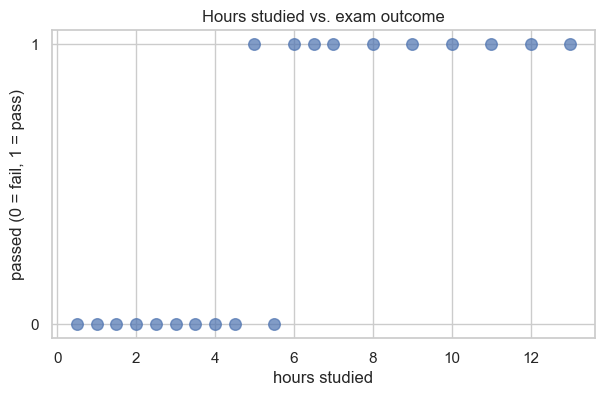

In [4]:
# Scatter plot — feature on x-axis, binary label on y-axis.
# The y values are either 0 or 1, so the dots line up on two horizontal levels.
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(study_df["hours_studied"], study_df["passed"], s=70, alpha=0.7)
ax.set_xlabel("hours studied")
ax.set_ylabel("passed (0 = fail, 1 = pass)")
ax.set_title("Hours studied vs. exam outcome")
ax.set_yticks([0, 1])
plt.show()


### Why a straight line cannot model this

Imagine fitting `passed = a + b * hours_studied` with ordinary linear regression.

- For a student who studied **13 hours**, the line might predict `1.4` — *meaningless* as a probability.
- For a student who studied **0 hours**, the line might predict `-0.2` — also meaningless.
- A probability has to live in **[0, 1]**. A straight line has no such constraint.

Logistic regression keeps the linear combination of features (`a + b * hours_studied`) and then squeezes the result through a **sigmoid** function that maps any real number into `(0, 1)`. The squeezed number is then read as the **probability of class 1**.

Next section: meet the sigmoid.

## §C. From probability to log-odds — the linear quantity logistic regression actually predicts

Logistic regression does **not** predict probabilities directly. It predicts **log-odds** — the natural log of the odds ratio, `log(p / (1 − p))` — and the sigmoid (next sub-section) converts those log-odds back to a probability for human reading. The reason is plain arithmetic:

- A **probability** is bounded in `[0, 1]`. A straight line `y = a + b * x` cannot stay inside that box (it eventually predicts values below 0 or above 1).
- The **odds** `p / (1 − p)` are bounded in `(0, ∞)` — better, but still asymmetric (always positive).
- The **log-odds** `log(p / (1 − p))` are unbounded in `(−∞, +∞)` — the exact shape a linear model needs to be fittable.

So logistic regression fits a line to the **log-odds**: `log-odds = a + b * x`. The sigmoid then maps that line back into `[0, 1]`.

**Small example** — three views of the same event:

| `p` (probability) | `p / (1 − p)` (odds) | `log(p / (1 − p))` (log-odds) |
| ---: | ---: | ---: |
| 0.10 | 1/9 | −2.20 |
| 0.25 | 1/3 | −1.10 |
| **0.50** | **1** | **0.00** |
| 0.75 | 3   | +1.10 |
| 0.90 | 9   | +2.20 |

**Reading:** a log-odds of **0** is a coin flip (the decision boundary); a log-odds of **+2.2** means the event is `e^2.2 ≈ 9×` more likely than not. Symmetric around `p = 0.5` — complementary probabilities (e.g. 0.25 vs 0.75) have opposite-sign log-odds of equal magnitude. An extra `+1` on the log-odds **multiplies the odds by `e ≈ 2.72`** — that's the rule of thumb for reading a fitted coefficient.

### §C.b The sigmoid — converting log-odds back into a probability

The sigmoid is the **inverse** of the log-odds transform — it takes a real-valued log-odds `z` and returns a probability in `(0, 1)`:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Properties worth memorising:

- Smooth **S-shape**, bounded between 0 and 1 — never exactly 0, never exactly 1.
- At `z = 0`, `σ(z) = 0.5` — the **default decision threshold**.
- The slope is steepest at `z = 0` and flattens out at the extremes — small changes in `z` near the middle move the probability a lot; near the tails they barely move it at all (non-constant returns).

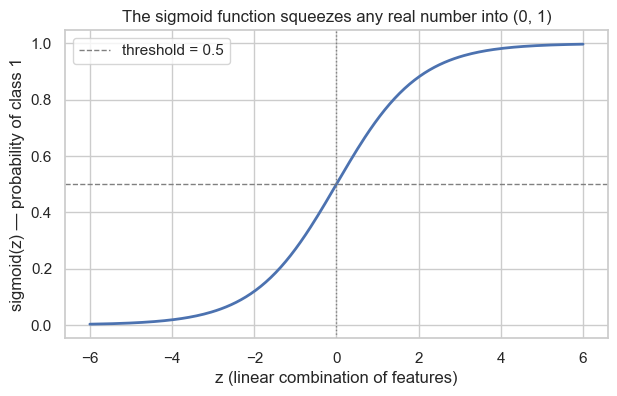

In [5]:
# Plot the sigmoid over a sensible range.
z = np.linspace(-6, 6, 200)
sigmoid_z = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z, sigmoid_z, linewidth=2)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, label="threshold = 0.5")
ax.axvline(0.0, color="grey", linestyle=":", linewidth=1)
ax.set_xlabel("z (linear combination of features)")
ax.set_ylabel("sigmoid(z) — probability of class 1")
ax.set_title("The sigmoid function squeezes any real number into (0, 1)")
ax.legend()
plt.show()


> ⏱ **Skip if running long.** The next markdown cell rewrites the sigmoid as `σ(z) = exp(z) / (1 + exp(z))` — same function, different algebra. Useful for the assumptions discussion in `lec_12c` but not needed for the rest of this notebook.

#### Optional: an equivalent form of the sigmoid

Multiplying top and bottom of `1 / (1 + e^{-z})` by `e^{z}` gives the equivalent expression:

$$\sigma(z) = \frac{e^{z}}{1 + e^{z}}$$

Both forms are used interchangeably in textbooks. The first form is more numerically stable for large positive `z`; the second is more stable for large negative `z`. Library implementations pick whichever is safer at runtime.

## §D. Fit logistic regression on the toy data and visualise

Scikit-learn API:

- `LogisticRegression()` — the model object.
- `.fit(X, y)` — learn the coefficients from the training data.
- `.predict(X_new)` — return the class label (0 or 1) after thresholding at 0.5.
- `.predict_proba(X_new)` — return the probability of each class.

We fit on the **whole** 20-row toy dataset (no train/test split for the first demo — we are visualising the fitted curve, not measuring generalisation).

In [6]:
# Feature matrix needs to be 2D for scikit-learn — even with one feature.
X_toy = study_df[["hours_studied"]]
y_toy = study_df["passed"]

logreg_toy = LogisticRegression(random_state=RANDOM_STATE)
logreg_toy.fit(X_toy, y_toy)

logreg_toy


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [7]:
# Inspect the learned coefficients.
print(f"intercept (a):  {logreg_toy.intercept_[0]:.3f}")
print(f"slope (b):      {logreg_toy.coef_[0][0]:.3f}")


intercept (a):  -6.812
slope (b):      1.288


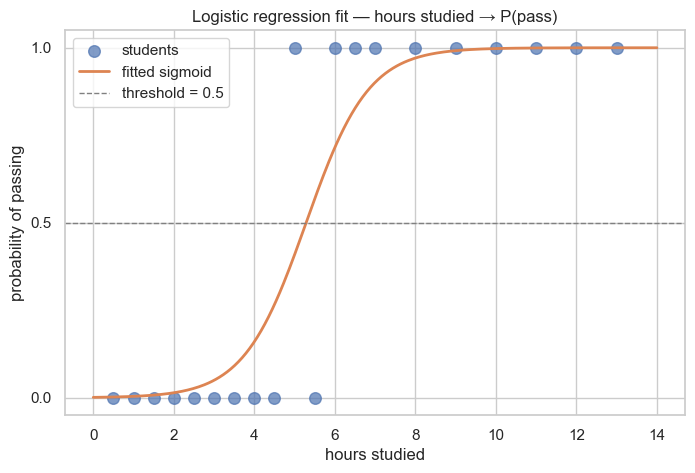

In [8]:
# Plot the fitted sigmoid on top of the scatter.
# Use a fine grid of hours-studied values, ask the model for predict_proba on each.
hours_grid = np.linspace(0, 14, 300).reshape(-1, 1)
hours_grid_df = pd.DataFrame(hours_grid, columns=["hours_studied"])
prob_pass = logreg_toy.predict_proba(hours_grid_df)[:, 1]  # column 1 = P(passed = 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(study_df["hours_studied"], study_df["passed"], s=70, alpha=0.7, label="students")
ax.plot(hours_grid, prob_pass, color="C1", linewidth=2, label="fitted sigmoid")
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, label="threshold = 0.5")
ax.set_xlabel("hours studied")
ax.set_ylabel("probability of passing")
ax.set_title("Logistic regression fit — hours studied → P(pass)")
ax.set_yticks([0, 0.5, 1])
ax.legend()
plt.show()


In [9]:
# Where does the fitted curve cross 0.5?
# That x-value is the decision boundary: above it the model predicts "pass", below it "fail".
# We can read it off the model: at the boundary, intercept + slope * hours = 0.
boundary_hours = -logreg_toy.intercept_[0] / logreg_toy.coef_[0][0]
print(f"Decision boundary: hours_studied = {boundary_hours:.2f}")
print(f"  -> students who studied less than this are predicted to FAIL")
print(f"  -> students who studied more than this are predicted to PASS")


Decision boundary: hours_studied = 5.29
  -> students who studied less than this are predicted to FAIL
  -> students who studied more than this are predicted to PASS


## §E. A small real binary example — heart-disease screening

The toy 20-row example shows the *mechanics*. To see logistic regression on something more realistic, we load a heart-disease screening dataset shipped alongside this notebook.

- **Target:** `Heart Disease` — `Presence` or `Absence`. We re-encode to `1` / `0`.
- **Features (we deliberately keep this small for interpretability):** `Age`, `Cholesterol`, `Max HR`.
- **Sample size:** the raw CSV has 630,000 rows. We subsample to 1,000 rows for fast execution — the model behaviour is the same, the lecture runs in seconds.
- **Split:** 80 / 20 train / test, **stratified** on the target so both splits carry the same class balance.

In [10]:
# Load the CSV that lives next to this notebook, then subsample.
heart_df_full = pd.read_csv("./predict_heart_disease_train.csv")
heart_df = heart_df_full.sample(n=1000, random_state=RANDOM_STATE).reset_index(drop=True)
heart_df.shape


(1000, 15)

In [11]:
# Look at a few rows so we know what we are working with.
heart_df.head(3)


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,364426,57,1,2,120,177,0,0,132,0,1.2,2,0,3,Absence
1,224752,41,1,4,132,274,0,2,122,0,0.0,1,0,3,Presence
2,110423,63,1,4,140,239,0,2,145,1,2.2,2,1,7,Presence


In [12]:
# Encode the target: Presence -> 1, Absence -> 0.
heart_df["target"] = (heart_df["Heart Disease"] == "Presence").astype(int)
heart_df["target"].value_counts()

target
0    576
1    424
Name: count, dtype: int64

In [ ]:
# Choose three interpretable features.
feature_cols = ["Age", "Cholesterol", "Max HR"]
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


X = heart_df[feature_cols]
y = heart_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"train class balance:\n{y_train.value_counts(normalize=True).round(3)}")


X_train shape: (800, 3)
X_test  shape: (200, 3)
train class balance:
target
0    0.576
1    0.424
Name: proportion, dtype: float64


In [ ]:
# Fit logistic regression on the training set.
# max_iter bumped from the default 100 to 1000 so the solver converges cleanly on this data.
logreg_heart = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
logreg_heart.fit(X_train, y_train)

logreg_heart
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [15]:
# Inspect the learned coefficients alongside the feature names.
pd.DataFrame({
    "feature":     feature_cols,
    "coefficient": logreg_heart.coef_[0],
}).round(4)


,feature,coefficient
0,Age,0.0604
1,Cholesterol,0.0059
2,Max HR,-0.0488


In [ ]:
# Score the model on the held-out test set.
y_pred = logreg_heart.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"test accuracy: {test_accuracy:.3f}")


test accuracy: 0.710


> ⏱ **Skip if running long.** The next code cell renders the confusion matrix as a small plot. The same information is in the printed accuracy above; the plot is useful when teaching the per-class read but is not load-bearing. The full confusion-matrix walk-through happens in `lec_12c` §E.

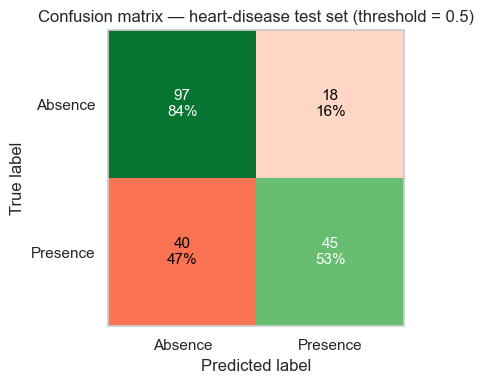

In [ ]:
# Confusion matrix — rows are true class, columns are predicted class.
# Colour convention (medical screening style):
#   diagonal cells (correct: TN, TP)        -> green shades (luminance = count)
#   off-diagonal  (errors:  FP, FN)         -> red   shades (luminance = count)
# The two colour scales make "correct vs. mistake" visible at a glance, which
# a single sequential palette (Blues) does not. FN — bottom-left — is the cell
# we care about most in screening: a sick patient predicted Absence walks out
# untreated.
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
labels_cm = ["Absence", "Presence"]
mask_diag = np.eye(2, dtype=bool)

# Row-normalise so cell colours are comparable across thresholds in the next cell.
row_sums = cm.sum(axis=1, keepdims=True)
cm_pct = cm / np.where(row_sums == 0, 1, row_sums)

# Build a per-cell RGBA array — Greens for the diagonal (correct), Reds for the
# off-diagonal (errors). Using a single imshow on the precomputed array avoids the
# thin white seams that appear when two imshows-with-NaN-masks are overlaid.
cm_rgba = np.zeros((2, 2, 4))
greens_cmap = plt.get_cmap("Greens")
reds_cmap   = plt.get_cmap("Reds")
for i in range(2):
    for j in range(2):
        cm_rgba[i, j] = greens_cmap(cm_pct[i, j]) if mask_diag[i, j] else reds_cmap(cm_pct[i, j])

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm_rgba, interpolation="nearest")
ax.grid(False)

# Annotate every cell with count + row-percentage.
for i in range(2):
    for j in range(2):
        text_color = "white" if cm_pct[i, j] > 0.5 else "black"
        ax.text(j, i, f"{cm[i, j]}\n{cm_pct[i, j]:.0%}",
                ha="center", va="center", color=text_color, fontsize=11)

ax.set_xticks([0, 1]); ax.set_xticklabels(labels_cm)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels_cm)
ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
ax.set_title("Confusion matrix — heart-disease test set (threshold = 0.5)")
plt.tight_layout()
plt.show()

### Lower the decision threshold — different confusion matrix, different trade-off

The 0.5 cutoff is a **convention**, not a law of physics. Logistic regression returns a probability; we choose where to draw the line.

In **disease screening** the costs are asymmetric:

- A **false negative** (missing a real disease) means a sick patient walks out untreated — the worst outcome.
- A **false positive** (flagging a healthy patient) means an extra round of testing — annoying, not life-threatening.

To make the model more aggressive at catching disease, **lower the threshold** (e.g. from 0.5 to 0.3). The model still produces the same probabilities; we just call "Presence" sooner.

Below we recompute the test-set confusion matrix at threshold **0.3** and compare to the default **0.5**. The plots use the **medical-screening colour convention**: green for diagonal (correct calls) and red for off-diagonal (errors), with darker shades meaning a larger share of that true-class row. Watch what shifts:

- **More true positives** (more sick patients caught) — the screening goal.
- **More false positives** (more healthy patients flagged) — the cost we accepted.
- **Fewer true negatives** and **fewer false negatives** — same coin, other side.

Whether this trade-off is worth it depends on the **cost of each error**, not on the model. That choice belongs to the clinician, not the data scientist.

--- threshold = 0.5  (default 0.5) ---
  TN=97  FP=18  FN=40  TP=45
  sensitivity (catch rate on Presence): 52.94%
  specificity (correct on Absence):     84.35%

--- threshold = 0.3  (screening 0.3) ---
  TN=62  FP=53  FN=18  TP=67
  sensitivity (catch rate on Presence): 78.82%
  specificity (correct on Absence):     53.91%



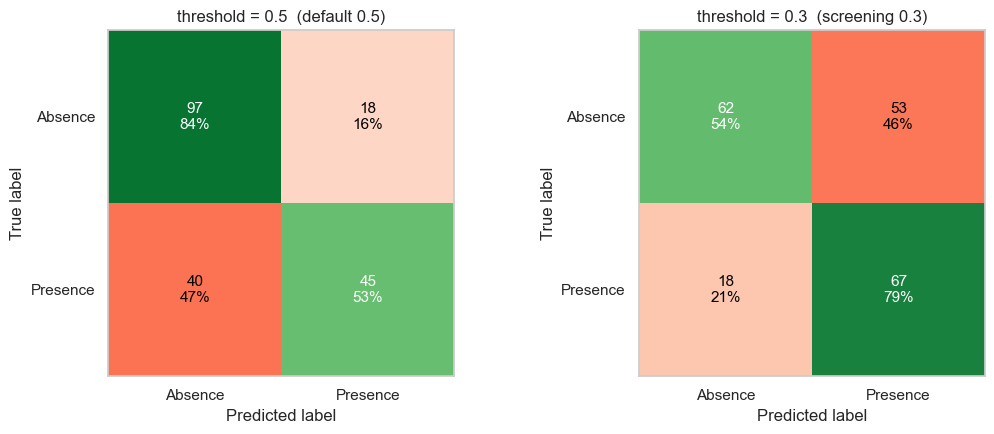

,accuracy,precision,recall,f1
threshold,,,,
0.5,0.710,0.714,0.529,0.608
0.3,0.645,0.558,0.788,0.654


In [ ]:
# Recompute predictions at two thresholds using predict_proba.
proba_presence = logreg_heart.predict_proba(X_test)[:, 1]  # column 1 = P(Presence = 1)

THRESHOLDS = [("default 0.5", 0.5), ("screening 0.3", 0.3)]
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

labels_cm = ["Absence", "Presence"]
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

mask_diag = np.eye(2, dtype=bool)

# Side-by-side confusion matrices in the medical-screening colour convention:
#   diagonal (correct: TN, TP)   -> green
#   off-diagonal (errors: FP, FN) -> red
# Lowering the threshold from 0.5 to 0.3 should turn the bottom-left FN cell
# lighter red (fewer missed sick patients) while the top-right FP cell turns
# darker red (more false alarms). That's the trade-off, visible as colour.
greens_cmap = plt.get_cmap("Greens")
reds_cmap   = plt.get_cmap("Reds")
metrics_rows = []
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, t) in zip(axes, THRESHOLDS):
    y_pred_t = (proba_presence >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t, labels=[0, 1])
    tn, fp, fn, tp = cm_t.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0   # recall on Presence (catch rate)
    specificity = tn / (tn + fp) if (tn + fp) else 0.0   # recall on Absence

    row_sums = cm_t.sum(axis=1, keepdims=True)
    cm_pct = cm_t / np.where(row_sums == 0, 1, row_sums)

    cm_rgba = np.zeros((2, 2, 4))
    for i in range(2):
        for j in range(2):
            cm_rgba[i, j] = greens_cmap(cm_pct[i, j]) if mask_diag[i, j] else reds_cmap(cm_pct[i, j])
    ax.imshow(cm_rgba, interpolation="nearest")
    ax.grid(False)
    for i in range(2):
        for j in range(2):
            text_color = "white" if cm_pct[i, j] > 0.5 else "black"
            ax.text(j, i, f"{cm_t[i, j]}\n{cm_pct[i, j]:.0%}",
                    ha="center", va="center", color=text_color, fontsize=11)
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels_cm)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels_cm)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title(f"threshold = {t}  ({name})")

    print(f"--- threshold = {t}  ({name}) ---")
    print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"  sensitivity (catch rate on Presence): {sensitivity:.2%}")
    print(f"  specificity (correct on Absence):     {specificity:.2%}")
    print()

    # Collect the four textbook metrics for the comparison table below.
    # F1 = harmonic mean of precision and recall — penalises imbalance between them.
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = sensitivity
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    metrics_rows.append({
        "threshold": t,
        "accuracy":  (tp + tn) / cm_t.sum(),
        "precision": precision,   # of predicted-Presence, how many are real?
        "recall":    recall,      # of real-Presence, how many did we catch?
        "f1":        f1,          # harmonic mean of precision and recall
    })

plt.tight_layout()
plt.show()

# Compare accuracy / precision / recall across the two thresholds.
metrics_df = pd.DataFrame(metrics_rows).set_index("threshold")
metrics_df.round(3)

**Accuracy / precision / recall comparison** (computed above, transcribed for the takeaway):

| metric              | threshold 0.5 | threshold 0.3 | direction | reading |
| --- | ---: | ---: | --- | --- |
| **accuracy**  *(overall correct)*           | 0.71 | 0.65 | ↓ | Lower — but accuracy mixes both error types and isn't the screening goal. |
| **precision** *(of predicted-Presence, how many are real?)* | 0.71 | 0.56 | ↓ | More false alarms among the patients we flagged. |
| **recall**    *(of real-Presence, how many did we catch?)*  | 0.53 | **0.79** | ↑ | We catch 26 percentage points more of the actually-sick patients — the whole point of lowering the threshold. |
| **F1**  *(harmonic mean of precision and recall)*           | 0.61 | **0.65** | ↑ | F1 penalises imbalance between precision and recall; here it agrees with the screening preference — the recall gain outweighs the precision loss. |

**Takeaway:**

- The default 0.5 cutoff **maximises accuracy** but misses about half the real cases. That's the wrong objective for a screening test.
- Lowering to 0.3 **maximises catch rate (recall)** at the cost of precision (more healthy patients re-screened) and a small drop in accuracy. **F1** — the single number that balances precision and recall — actually *improves* (0.61 → 0.65), because the recall gain (+0.26) dominates the precision loss (−0.15).
- In medical screening, **recall typically wins** — re-testing a healthy person is cheap, missing a sick one is expensive.
- The right threshold is a **clinical and economic** decision, not a statistical one. Logistic regression gives you the probabilities; you decide where to cut.

### Look at three example predictions individually

Until now we have looked at *aggregate* accuracy. Logistic regression's headline feature is that it also gives you a **per-observation probability** — useful when you want to rank patients by risk, not just label them.

In [19]:
# Pick 3 test-set rows and show their probabilities side by side with the predicted class.
sample_rows = X_test.head(3)
sample_probs = logreg_heart.predict_proba(sample_rows)
sample_preds = logreg_heart.predict(sample_rows)

results = sample_rows.copy()
results["P(Absence)"]  = sample_probs[:, 0].round(3)
results["P(Presence)"] = sample_probs[:, 1].round(3)
results["predicted"]   = ["Presence" if p == 1 else "Absence" for p in sample_preds]
results


,Age,Cholesterol,Max HR,P(Absence),P(Presence),predicted
478,49,269,161,0.720,0.280,Absence
851,41,204,163,0.871,0.129,Absence
291,58,198,96,0.087,0.913,Presence


In [20]:
# Read one of the rows out loud so the proba -> class step is obvious.
row_idx = 0
prob_presence = sample_probs[row_idx, 1]
predicted    = "Presence" if prob_presence >= 0.5 else "Absence"
print(f"This patient: P(Presence) = {prob_presence:.3f} -> predicted {predicted}")


This patient: P(Presence) = 0.280 -> predicted Absence


## §F. When to reach for logistic regression — and when not to

### Reach for logistic regression when

- The target is **binary** or a small multi-class set (≤ ~10 classes).
- You want **interpretable per-feature effects** — each coefficient tells you the direction and (after exponentiating) the multiplicative effect on the odds.
- You want **calibrated probabilities** out of the box — useful when the downstream decision depends on a probability, not just a class.
- The relationship between features and the **log-odds** of the target is approximately linear. (Note: the relationship to the probability is non-linear because of the sigmoid; the relationship to the log-odds is linear. More in `lec_12c` §B.)
- You have **more samples than features** — typically by a factor of 10 or more.

### Reach elsewhere when

- Features have strong **non-linear interactions** you cannot manually engineer — try tree-based models (`lec_12e` covers Naive Bayes; gradient-boosted trees are in a later course) or SVM with an RBF kernel (`lec_12f`).
- The data is **very high-dimensional and sparse** — for text classification with word counts, **Naive Bayes** (`lec_12e`) is a faster baseline.
- The decision boundary is clearly **non-linear** and you do not want to engineer polynomial / interaction features by hand — try **SVM with an RBF kernel** (`lec_12f`).
- You need a model that handles **missing values natively** — logistic regression does not; you must impute first.

## §G. Where logistic regression earns its keep on the job

Logistic regression is rarely the *flashiest* model in a production system. It is almost always one of the *most used*.

- **The building block of deep learning.** A biological neuron receives weighted inputs from other neurons (along its dendrites), sums them at the cell body, and fires — or doesn't — through a non-linear threshold. Logistic regression is the mathematical caricature of this: a *weighted sum of features* followed by a *sigmoid that decides how strongly to fire*. The 1958 perceptron and McCulloch–Pitts neuron started here. **Stack many logistic units in layers and you have a multi-layer perceptron — the original neural network.** Modern deep nets are mostly weighted sums + non-linearities trained by gradient descent; the **final classifier head** of most networks (and of every LLM you have used) is literally a logistic / softmax regression on the layer below. Understanding what a sigmoid does to a linear predictor is the smallest unit of understanding what a neural network does to its inputs.
- **The default classifier in regulated industries.** Every retail bank uses logistic regression for credit scoring; every public-health agency uses it for screening models; every clinical study uses it for binary outcomes. The reason is the same in all three: **interpretability is a regulatory requirement**, and logistic regression coefficients are the easiest to defend in front of a regulator or an ethics committee.
- **The honest baseline.** Even when the deployed model is a deep neural network or a gradient-boosted tree, logistic regression is usually the **baseline** that proves the deep model is worth its added cost and complexity. If your fancy model cannot beat a well-tuned logistic regression by a meaningful margin, the data is the bottleneck, not the algorithm. Every working data scientist runs this check first.

## §H. Recap and forward pointers

### What landed in this notebook

- **Logistic regression solves classification, not regression.** Continuous target → linear regression (Lecture 11). Discrete class label → logistic regression. The difference is the target, not the features.
- **The sigmoid is the trick.** Take any linear combination of features, push it through `σ(z) = 1 / (1 + e^{-z})`, and you get a probability in `(0, 1)`. Threshold at 0.5 to turn the probability into a class.
- **Reach for LR when** the target is binary or small-multi-class, you need interpretable per-feature effects, and the relationship is approximately linear in the log-odds.

### Where to read next

- **`lec_12b`** — fit the same model with **three Python APIs** (`statsmodels.Logit`, `pingouin.logistic_regression`, `sklearn.LogisticRegression`) and read the **four output quantities** a logistic-regression fit produces: the linear predictor (`decision_function`), the probit alternative, the probability (`predict_proba`), and the class (`predict`).
- **`lec_12c`** — the honest limitations: linearity of the logit, multicollinearity, perfect separation, class imbalance and the 0.5-threshold trap, the silent default L2 in scikit-learn.

## Further reading

- [Sigmoid function — Wikipedia](https://en.wikipedia.org/wiki/Sigmoid_function) — the function family logistic regression uses for its output transform.
- [scikit-learn user guide §1.1.11 — Logistic Regression](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression) — the canonical reference for sklearn's API, including the solver / penalty matrix that drives `lec_12d`.
- [Wikipedia — Logistic regression](https://en.wikipedia.org/wiki/Logistic_regression) — the textbook treatment of the hours-studied / pass-exam example used in §B.